# House Price Prediction using Machine Learning



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import pandas as pd

df = pd.read_csv("/content/house_price_dataset.csv")

df.head()
print("Shape:", df.shape)
df.columns
df.info()



Shape: (1200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area_sqft  1200 non-null   int64  
 1   Bedrooms   1200 non-null   int64  
 2   Bathrooms  1188 non-null   float64
 3   Stories    1200 non-null   int64  
 4   Parking    1188 non-null   float64
 5   Location   1200 non-null   object 
 6   Age_years  1188 non-null   float64
 7   Price      1200 non-null   int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 75.1+ KB


## Understanding and Exploring the Dataset

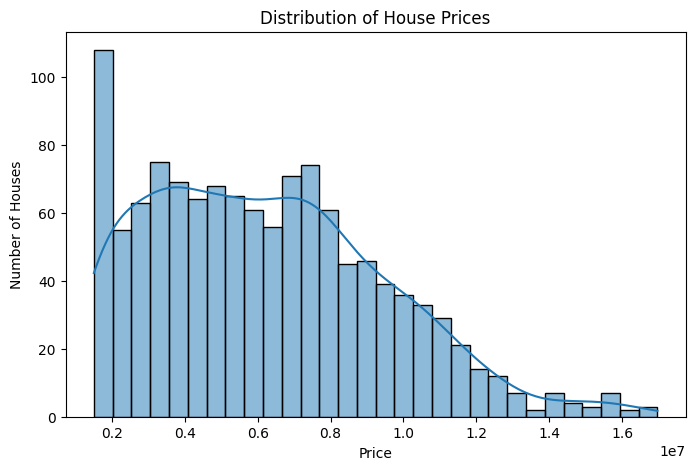

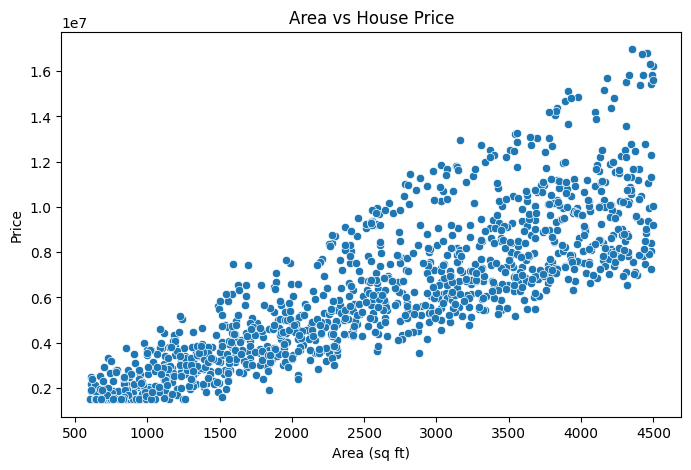

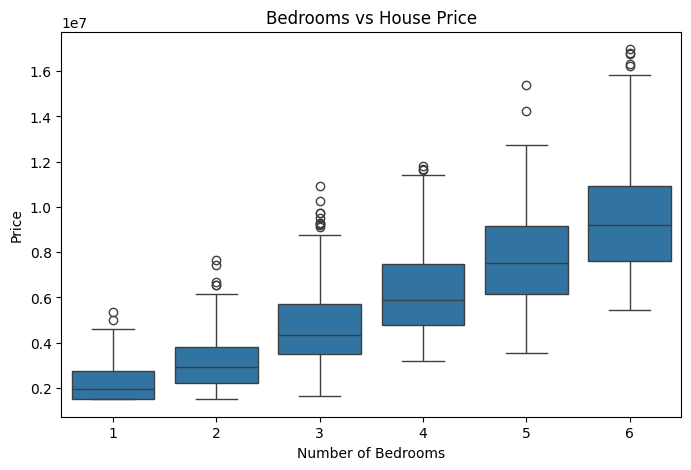

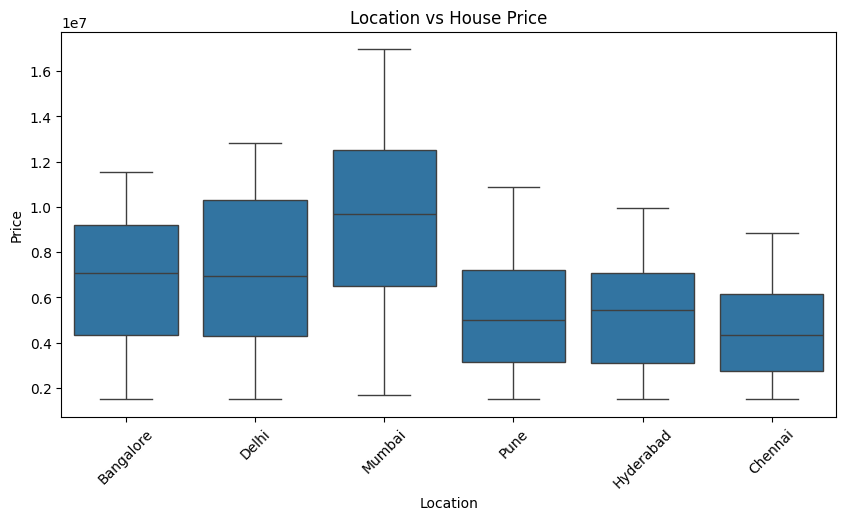

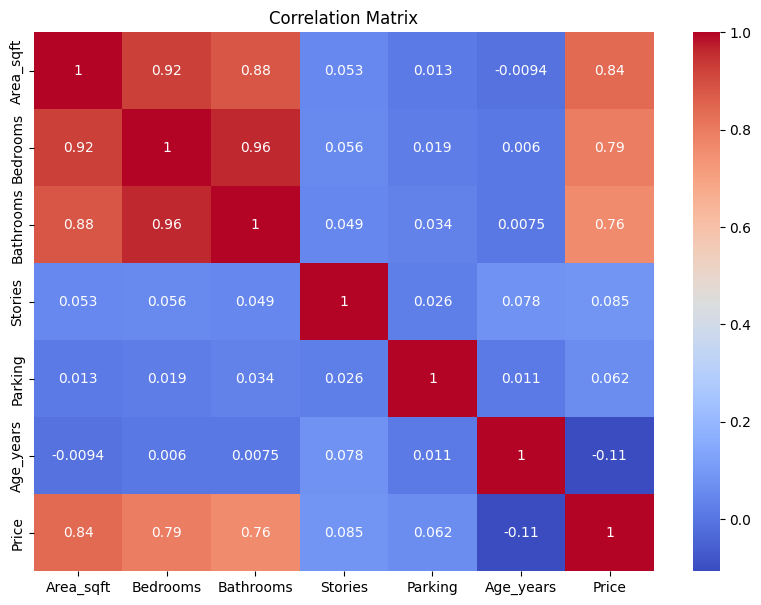

In [ ]:
##checking the missing values
df.isnull().sum()
##checking duplicates
df.duplicated().sum()
df.describe()
df["Location"].value_counts()
##Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()
##Area vs price
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Area_sqft",
    y="Price"
)

plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")

plt.show()


##Bedroom vs price
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Bedrooms",
    y="Price"
)

plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")

plt.show()

##Location vs Price

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Location",
    y="Price"
)

plt.title("Location vs House Price")
plt.xlabel("Location")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.show()

##correlation Matrix

df.corr(numeric_only=True)
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()


## Data Cleaning and Preprocessing

In this section, we clean the dataset, handle missing values, identify outliers, encode categorical variables, separate features from the target, and prepare the data for machine learning.

In [ ]:
# Create a copy
data = df.copy()

# Check missing values
print("Missing values before cleaning:")
print(data.isnull().sum())

# Handle missing values using median
data["Bathrooms"] = data["Bathrooms"].fillna(
    data["Bathrooms"].median()
)

data["Parking"] = data["Parking"].fillna(
    data["Parking"].median()
)

data["Age_years"] = data["Age_years"].fillna(
    data["Age_years"].median()
)

# Check missing values again
print("\nMissing values after cleaning:")
print(data.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", data.duplicated().sum())

# One-hot encode Location
data = pd.get_dummies(
    data,
    columns=["Location"],
    drop_first=True
)

# Separate features and target
X = data.drop("Price", axis=1)
y = data["Price"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Missing values before cleaning:
Area_sqft     0
Bedrooms      0
Bathrooms    12
Stories       0
Parking      12
Location      0
Age_years    12
Price         0
dtype: int64

Missing values after cleaning:
Area_sqft    0
Bedrooms     0
Bathrooms    0
Stories      0
Parking      0
Location     0
Age_years    0
Price        0
dtype: int64

Duplicate rows: 0

X_train: (960, 11)
X_test: (240, 11)
y_train: (960,)
y_test: (240,)


### Model Building(Linear Regression)

In [ ]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Create model(linear Regession)
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Display intercept
print("Intercept:", model.intercept_)

# Display coefficients
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print("\nCoefficients:")
display(coefficients)

# Make predictions
y_pred = model.predict(X_test)

# Compare actual and predicted values
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10]
})

print("\nActual vs Predicted:")
display(comparison)

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Intercept: 379259.9227695912

Coefficients:


,Feature,Coefficient
0,Area_sqft,1.899692e+03
1,Bedrooms,2.586205e+05
2,Bathrooms,9.377626e+04
3,Stories,6.498734e+04
4,Parking,1.267073e+05
5,Age_years,-3.363369e+04
6,Location_Chennai,-1.617914e+06
7,Location_Delhi,7.492795e+05
8,Location_Hyderabad,-1.579359e+06
9,Location_Mumbai,2.911599e+06



Actual vs Predicted:


,Actual Price,Predicted Price
0,7489000,7.945543e+06
1,4438000,4.759070e+06
2,6943000,6.750749e+06
3,3461000,3.427662e+06
4,7823000,8.309873e+06
5,3523000,3.953040e+06
6,9947000,9.642630e+06
7,3036000,3.041886e+06
8,5054000,5.591135e+06
9,7907000,8.332320e+06



Model Performance
------------------
MAE : 605210.8317813178
MSE : 594725303475.3289
RMSE: 771184.351160816
R²  : 0.943052755322867


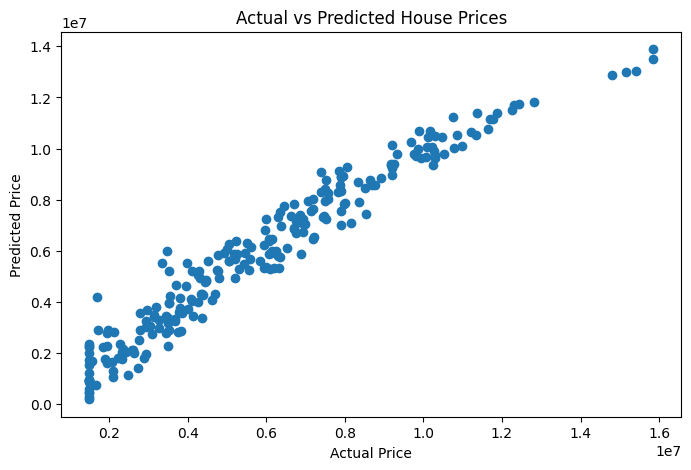

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

 ### Model Comparison: Decision Tree vs Random Forest

In [ ]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Decision Tree

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree")
print("MAE :", tree_mae)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)


# ------------------------------
# Random Forest
# ------------------------------

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

# Model Comparison

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2 Score": [
        r2,
        tree_r2,
        rf_r2
    ]
})

print("\nModel Comparison:")
display(results)

Decision Tree
MAE : 631804.1666666666
RMSE: 800459.0948324592
R²  : 0.9386471719296103

Random Forest
MAE : 495823.6666666667
RMSE: 618181.9854777125
R²  : 0.9634077605083791

Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,605210.831781,771184.351161,0.943053
1,Decision Tree,631804.166667,800459.094832,0.938647
2,Random Forest,495823.666667,618181.985478,0.963408


###Hyperparameter Tuning and Final Model Selection.

In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest
rf = RandomForestRegressor(
    random_state=42
)

# Hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Train and search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best model
best_rf = grid_search.best_estimator_

# Prediction
best_pred = best_rf.predict(X_test)

# Evaluation
best_mae = mean_absolute_error(y_test, best_pred)
best_mse = mean_squared_error(y_test, best_pred)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_pred)

print("\nTuned Random Forest Performance")
print("--------------------------------")
print("MAE :", best_mae)
print("RMSE:", best_rmse)
print("R²  :", best_r2)

# Save final model
import joblib

joblib.dump(
    best_rf,
    "house_price_model.pkl"
)

print("\nModel saved successfully!")

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Tuned Random Forest Performance
--------------------------------
MAE : 493217.9841642355
RMSE: 617269.847973458
R²  : 0.9635156657224537

Model saved successfully!


###Building a User Prediction System

In [ ]:
def predict_house_price(
    area,
    bedrooms,
    bathrooms,
    stories,
    parking,
    location,
    age
):

    # Create input dictionary
    input_data = {
        "Area_sqft": area,
        "Bedrooms": bedrooms,
        "Bathrooms": bathrooms,
        "Stories": stories,
        "Parking": parking,
        "Age_years": age
    }

    # Create all location columns
    for column in X_train.columns:
        if column.startswith("Location_"):
            input_data[column] = 0

    # Set selected location
    location_column = "Location_" + location

    if location_column in input_data:
        input_data[location_column] = 1
    else:
        raise ValueError(
            "Location not available in the training dataset."
        )

    # Convert to DataFrame
    input_df = pd.DataFrame([input_data])

    # Ensure same feature order
    input_df = input_df[X_train.columns]

    # Make prediction
    prediction = best_rf.predict(input_df)

    return prediction[0]



In [ ]:
price = predict_house_price(
    area=2000,
    bedrooms=3,
    bathrooms=2,
    stories=2,
    parking=1,
    location="Hyderabad",
    age=5
)

print(f"Predicted House Price: ₹{price:,.2f}")

Predicted House Price: ₹4,130,620.78


In [ ]:
price = predict_house_price(
    area=3000,
    bedrooms=4,
    bathrooms=3,
    stories=2,
    parking=2,
    location="Hyderabad",
    age=3
)

print(f"Predicted House Price: ₹{price:,.2f}")

Predicted House Price: ₹5,918,945.02


In [ ]:
import os

print(os.path.exists("house_price_model.pkl"))

True
